In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.drop("target", axis=1).shape)
print(df["target"].nunique())
display(df.head())


X = df.drop("target", axis=1)
y = df["target"]


(569, 30)
2


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y 
)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)          

In [5]:
log_reg = LogisticRegression(
    max_iter=2000,  
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [6]:
y_pred = log_reg.predict(X_test_scaled)  
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]  

In [7]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring="accuracy")
print("\nCross-Validation روی Train (5-fold):")
print(f"Accuracy: {cv_scores.mean():.4f} ,  {cv_scores.std():.4f}")

Accuracy : 0.9883
Precision: 0.9907
Recall   : 0.9907
F1-score : 0.9907

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        64
           1       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171


Cross-Validation روی Train (5-fold):
Accuracy: 0.9799 ,  0.0150


Text(195.72222222222223, 0.5, 'Actual')

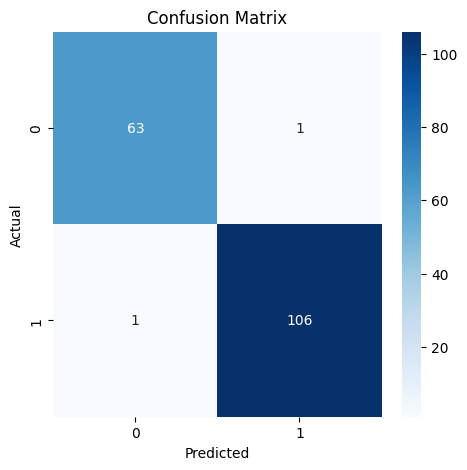

In [12]:
plt.figure(figsize=(18, 5))
ax1 = plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1)
ax1.set_title("Confusion Matrix")
ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")

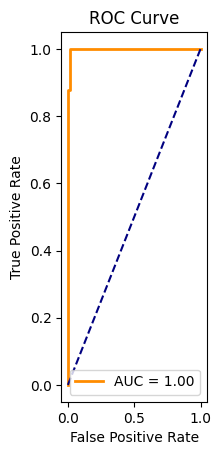

In [13]:

ax2 = plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.2f}")
ax2.plot([0, 1], [0, 1], color="navy", linestyle="--")
ax2.set_title("ROC Curve")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(loc="lower right")

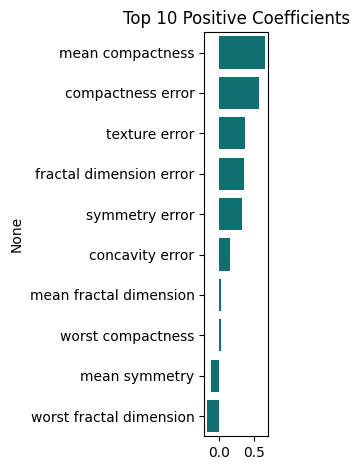

In [14]:
ax3 = plt.subplot(1, 3, 3)
coef_series = pd.Series(log_reg.coef_[0], index=data.feature_names).sort_values(ascending=False)

top_n = 10
top_coefs = coef_series.head(top_n)

sns.barplot(x=top_coefs.values, y=top_coefs.index, ax=ax3, color="teal")
ax3.set_title(f"Top {top_n} Positive Coefficients")

plt.tight_layout()
plt.show()